# 04 · Customer Segmentation
K-Means clustering on behavioral/value features, plus segment, geography, and device performance.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.model import CustomerSegmentation
from src.dashboard_metrics import segment_performance, geo_performance, device_performance

customers = pd.read_csv('../data/processed/customers_clean.csv', parse_dates=['signup_date','purchase_date'])

## Declared Segment Performance

In [2]:
segment_performance(customers)

,customer_segment,customers,avg_ltv,total_ltv,avg_orders
3,High Value,842,1195.626900,1006717.85,12.042755
2,Growth,1401,427.253726,598582.47,3.990721
4,New Acquisition,1588,219.676618,348846.47,2.138539
0,At Risk,924,181.068994,167307.75,1.977273
1,Dormant,645,73.314884,47288.10,1.277519


## K-Means Clustering (Behavioral Segmentation)
Using `lifetime_value`, `total_orders`, and `age` as clustering features, standardized before fitting.

In [3]:
seg = CustomerSegmentation(n_clusters=4)
customers['cluster'] = seg.fit_predict(customers)
customers.groupby('cluster')[['lifetime_value','total_orders','age']].mean().round(2)

,lifetime_value,total_orders,age
cluster,,,
0,259.63,2.54,30.48
1,249.31,2.51,56.63
2,1859.64,12.02,43.87
3,808.48,12.12,45.41


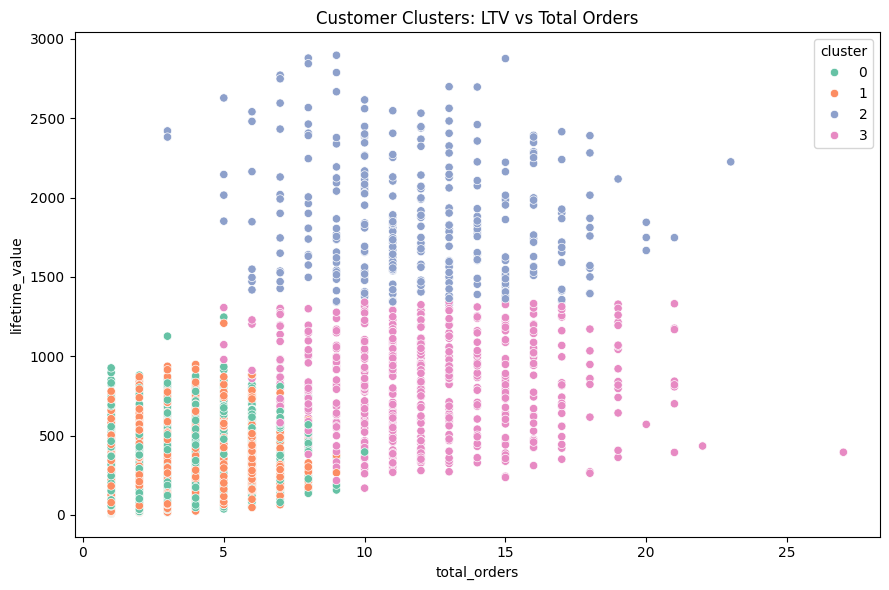

In [4]:
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=customers, x='total_orders', y='lifetime_value', hue='cluster', palette='Set2', ax=ax)
ax.set_title('Customer Clusters: LTV vs Total Orders')
plt.tight_layout(); plt.show()

## Geography & Device Performance

In [5]:
geo_performance(customers)

,country,customers,avg_ltv,total_ltv
2,Germany,773,418.968202,323862.42
4,Singapore,794,403.817191,320630.85
1,Canada,789,405.274905,319761.90
5,United Kingdom,795,400.729975,318580.33
6,United States,764,398.350746,304339.97
0,Australia,764,389.819738,297822.28
3,India,721,393.543537,283744.89


In [6]:
device_performance(customers)

,device,customers,avg_ltv
2,Tablet,350,420.175829
0,Desktop,2382,412.850374
1,Mobile,2668,389.157238


### Insight
The K-Means clusters largely mirror the declared `customer_segment` labels but reveal a distinct high-value, low-frequency micro-segment (cluster with highest LTV/lowest order count) — good targets for a premium retention campaign rather than a volume-based acquisition play.